# Bacotypes of Klebsiella 

In [1]:
# Imports
import anndata as ad
import scanpy as sc
import pandas as pd

/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:388: SyntaxWarning: invalid escape sequence '\m'
  """ Implements modularity. This quality function is well-defined only for positive edge weights.
/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:761: SyntaxWarning: invalid escape sequence '\m'
  """ Implements Reichardt and Bornholdt's Potts model with a configuration null model.
/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:7: SyntaxWarning: invalid escape sequence '\g'
  """ Class for doing community detection using the Leiden algorithm.
/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:305: SyntaxWarning: invalid escape sequence '\s'
  """ Optimise the given partitions simultaneously.


In [2]:
# Embeddings
embeddings_file = "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/klebsiella_genome_embeddings.pq"
embeddings = pd.read_parquet(embeddings_file, engine="pyarrow")
metadata_file = "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/final/metadata_final_curated_slimmed.tsv"
metadata = pd.read_csv(metadata_file, sep="\t")

print("Embeddings shape:", embeddings.shape)
print("Embeddings index (first 5):", embeddings.index[:5])
print("Metadata shape before indexing:", metadata.shape)
print("Metadata columns:", metadata.columns.tolist())

# Set metadata index to Sample column to link with embeddings index (sample_id)
metadata = metadata.set_index('Sample')

print("Metadata index name after set_index:", metadata.index.name)
print("Metadata index (first 5):", metadata.index[:5])

# Align metadata with embeddings index to ensure proper matching
metadata_aligned = metadata.reindex(embeddings.index)

print("Aligned metadata shape:", metadata_aligned.shape)
print("Number of missing metadata rows after alignment:", metadata_aligned.isna().all(axis=1).sum())

# Make an AnnData object with aligned metadata
# All metadata columns will be available in adata.obs for annotation
adata = ad.AnnData(X=embeddings.values, obs=metadata_aligned)

print("AnnData X shape:", adata.X.shape)
print("AnnData obs shape:", adata.obs.shape)

# Add embeddings to the AnnData object
adata.obsm["X_emb"] = embeddings.values

/tmp/ipykernel_1788286/2923161086.py:5: DtypeWarning: Columns (20,133,136,138,152,153,154,155,156) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(metadata_file, sep="\t")


Embeddings shape: (57929, 960)
Embeddings index (first 5): Index(['SAMD00052614', 'SAMD00052625', 'SAMD00055758', 'SAMD00052615',
       'SAMD00052623'],
      dtype='object', name='sample_id')
Metadata shape before indexing: (88303, 157)
Metadata columns: ['Sample', 'is_kpsc', 'kpsc_final_list', 'is_refseq', 'is_nctc', 'species', 'species_match', 'Clonal group', 'LINcode', 'Phylogroup', 'Sublineage', 'scgST', 'contig_count', 'N50', 'largest_contig', 'total_size', 'ambiguous_bases', 'QC_warnings', 'ST', 'gapA', 'infB', 'mdh', 'pgi', 'phoE', 'rpoB', 'tonB', 'YbST', 'Yersiniabactin', 'ybtS', 'ybtX', 'ybtQ', 'ybtP', 'ybtA', 'irp2', 'irp1', 'ybtU', 'ybtT', 'ybtE', 'fyuA', 'spurious_ybt_hits', 'CbST', 'Colibactin', 'clbA', 'clbB', 'clbC', 'clbD', 'clbE', 'clbF', 'clbG', 'clbH', 'clbI', 'clbL', 'clbM', 'clbN', 'clbO', 'clbP', 'clbQ', 'spurious_clb_hits', 'AbST', 'Aerobactin', 'iucA', 'iucB', 'iucC', 'iucD', 'iutA', 'spurious_abst_hits', 'SmST', 'Salmochelin', 'iroB', 'iroC', 'iroD', 'iroN', 

In [3]:
# compute neighbors with scanpy
sc.pp.neighbors(adata, use_rep="X_emb")
# compute UMAP
sc.tl.umap(adata)

/tmp/ipykernel_1788286/670417244.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.25)


Leiden cluster sizes (top 5 + other): leiden_top
0        16346
1        16020
2        15051
3         7932
4         2414
other      166
Name: count, dtype: int64


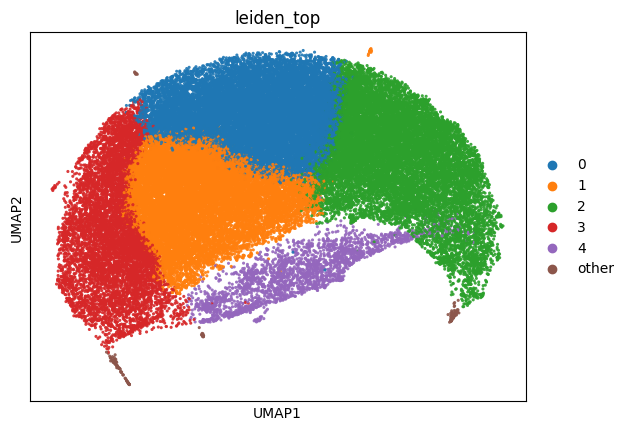

In [4]:
# Leiden clustering with resolution 0.5
sc.tl.leiden(adata, resolution=0.25)

# Group top 5 Leiden clusters, rest as 'other'
n_top_clusters = 5
cluster_sizes = adata.obs['leiden'].value_counts()
top_clusters = cluster_sizes.head(n_top_clusters).index
leiden_str = adata.obs['leiden'].astype(str)
adata.obs['leiden_top'] = leiden_str.where(leiden_str.isin([str(c) for c in top_clusters]), other='other')
adata.obs['leiden_top'] = adata.obs['leiden_top'].astype('category')

print("Leiden cluster sizes (top 5 + other):", adata.obs['leiden_top'].value_counts())

sc.pl.umap(
    adata,
    color='leiden_top',
    size=20,
    alpha=0.9,
)

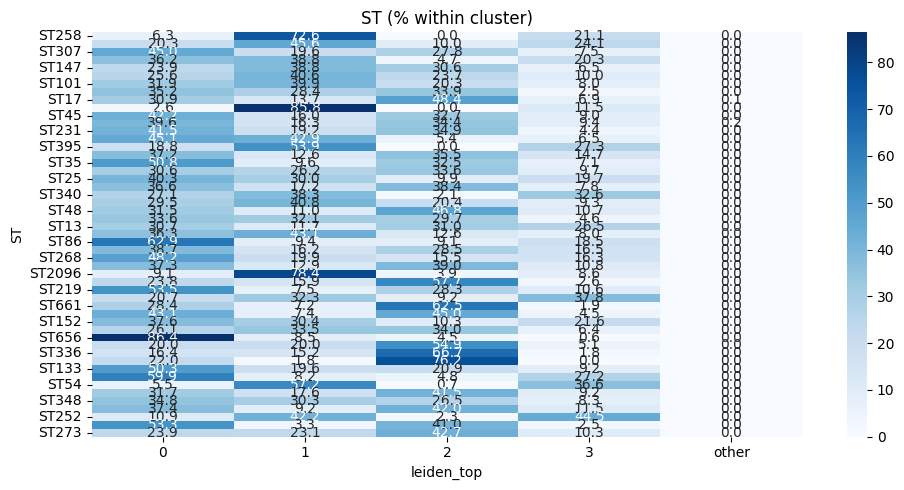

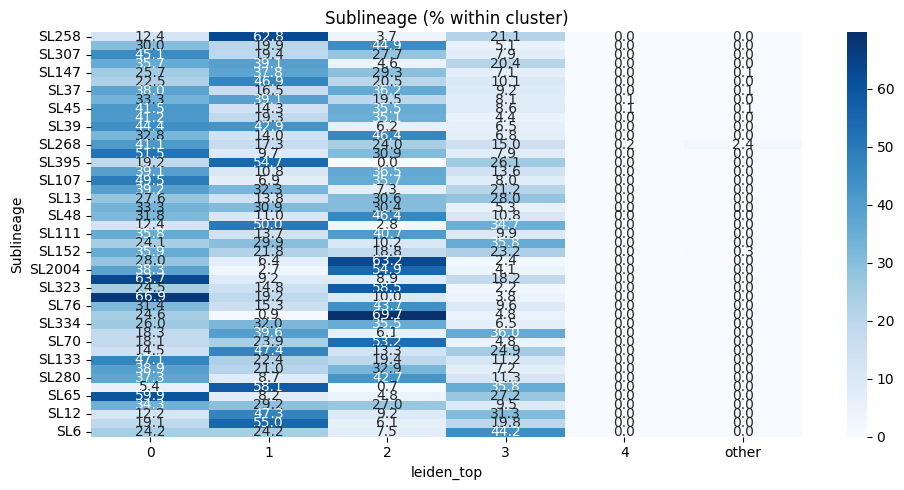

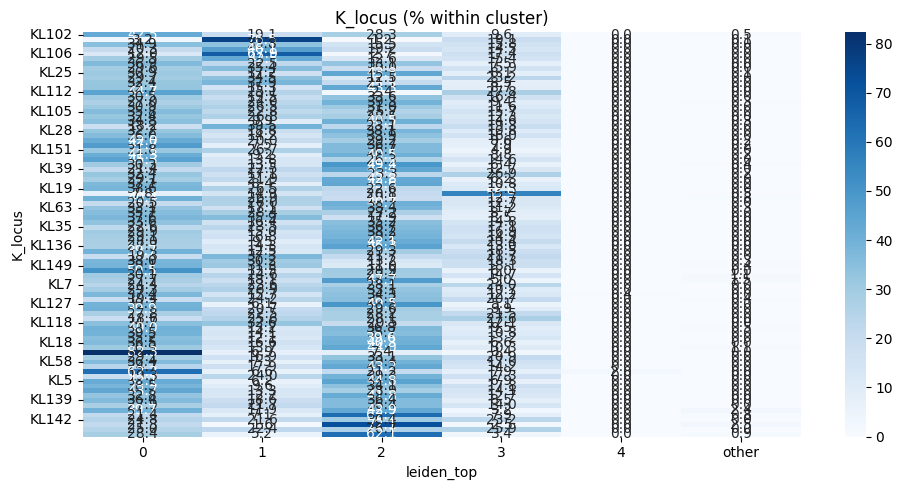

In [5]:
# Heatmaps of variable categories by leiden_top cluster
import matplotlib.pyplot as plt
import seaborn as sns

cross_variables = ['ST', "Sublineage", "K_locus"]
min_pct_population = 0.2  # Only include rows where at least one cell value > this

for var in cross_variables:
    if var not in adata.obs.columns:
        print(f"Warning: {var} not found in adata.obs.columns, skipping...")
        continue
    value_counts = adata.obs[var].value_counts()
    total_count = len(adata.obs)
    pct_of_population = (value_counts / total_count) * 100
    # Keep only values that meet the threshold
    values_to_keep = pct_of_population[pct_of_population >= min_pct_population].index
    # Filter the data to only these values
    filtered_obs = adata.obs[adata.obs[var].isin(values_to_keep)]
    # Now create crosstab with filtered data
    contingency = pd.crosstab(filtered_obs[var], filtered_obs['leiden_top'])
    # Calculate percentages within each cluster
    pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
    
    # Sort rows by population percentage (descending)
    # Get the filtered population percentages in the same order as pct index
    sort_order = pct_of_population[pct.index].sort_values(ascending=False).index
    pct = pct.loc[sort_order]
    
    fig, ax = plt.subplots(figsize=(max(10, pct.shape[1] * 0.3), 5))
    sns.heatmap(pct, annot=True, fmt='.1f', cmap='Blues', ax=ax)
    ax.set_title(f'{var} (% within cluster)')
    ax.set_ylabel(var)
    ax.set_xlabel('leiden_top')
    plt.tight_layout()
    plt.show()

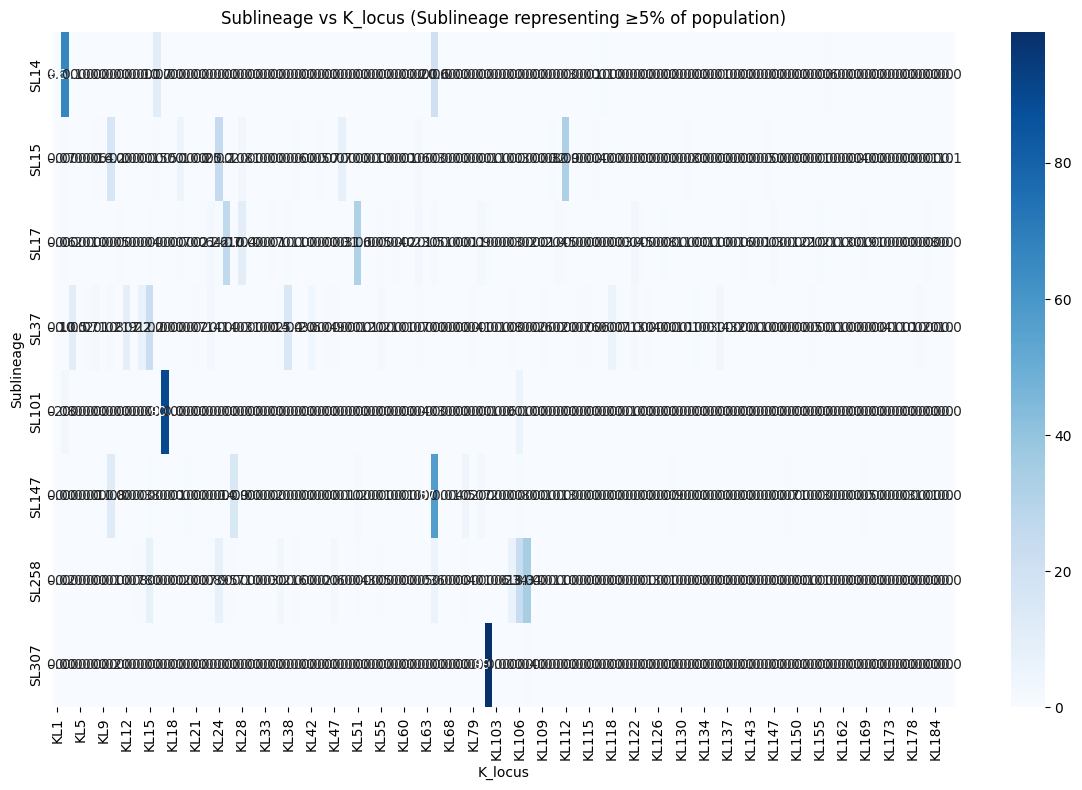

In [6]:
# Define threshold
min_pct_population = 2

# Filter ST values to only those representing >= 5% of population
st_counts = adata.obs['Sublineage'].value_counts()
total_count = len(adata.obs)
st_pct_of_population = (st_counts / total_count) * 100

# Keep only ST values that meet the threshold
sts_to_keep = st_pct_of_population[st_pct_of_population >= min_pct_population].index

# Filter the data to only these STs
filtered_obs = adata.obs[adata.obs['Sublineage'].isin(sts_to_keep)]

# Create a contingency table with filtered data
contingency = pd.crosstab(filtered_obs['Sublineage'], filtered_obs['K_locus'])

# Calculate percentages within each ST (across K_locus values)
pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

# Create a heatmap of the percentages
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pct, annot=True, fmt='.1f', cmap='Blues', ax=ax)
ax.set_title('Sublineage vs K_locus (Sublineage representing ≥5% of population)')
ax.set_xlabel('K_locus')
ax.set_ylabel('Sublineage')
plt.tight_layout()
plt.show()

Plotting with 15760 samples (filtered to top 5 Clonal groups)


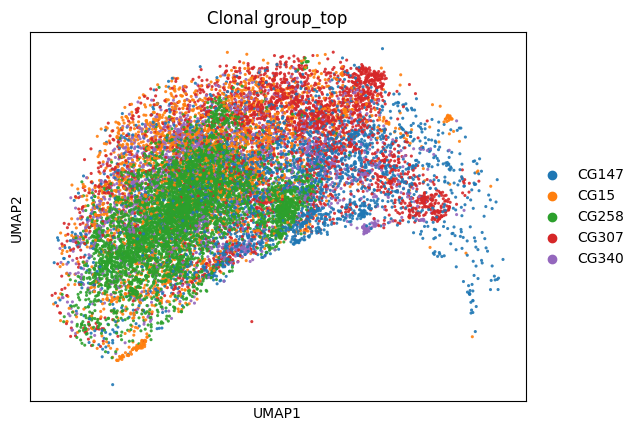

Plotting with 20838 samples (filtered to top 5 Sublineages)


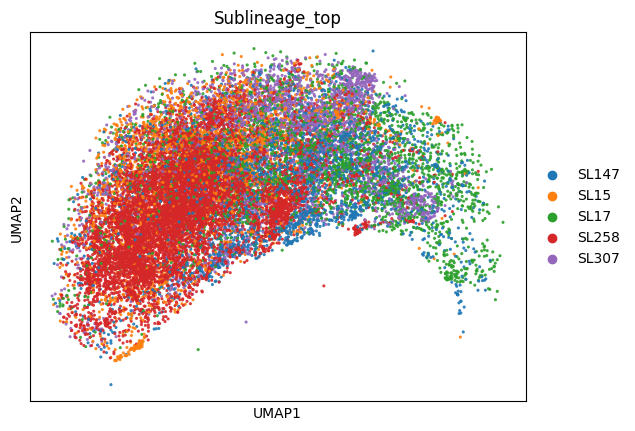

Plotting with 15055 samples (filtered to top 5 K_locuss)


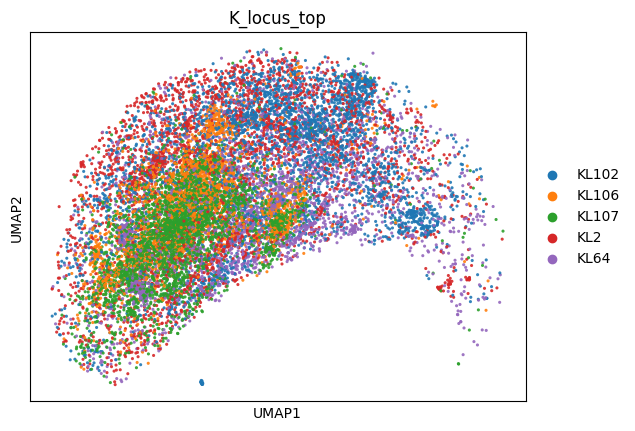

Plotting with 46595 samples (filtered to top 5 O_locuss)


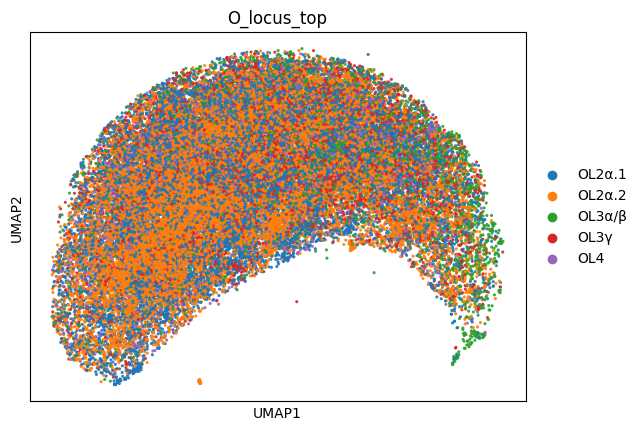

In [7]:
factors_of_interest = ['Clonal group', "Sublineage", "K_locus", "O_locus"]
# Option to filter out 'other' samples (True) or include them as 'other' category (False)
filter_other = True

for factor in factors_of_interest:
    # Create ST grouping: top 5 most frequent STs, rest as 'other'
    factor_counts = adata.obs[factor].value_counts()
    n_top_factor = 5
    top_factor = factor_counts.head(n_top_factor).index

    # Always create ST_top column on the full dataset
    top_factor_name = f'{factor}_top'
    top_factor_str = adata.obs[factor].astype(str)
    if filter_other:
        # Mark top STs, others will be filtered for plotting
        adata.obs[top_factor_name] = top_factor_str.where(top_factor_str.isin([str(st) for st in top_factor]), other=None)
    else:
        # Keep all samples, mark non-top STs as 'other'
        adata.obs[top_factor_name] = top_factor_str.where(top_factor_str.isin([str(st) for st in top_factor]), other='other')

    adata.obs[top_factor_name] = adata.obs[top_factor_name].astype('category')

    # Create filtered view for plotting if needed
    if filter_other:
        plot_data = adata[adata.obs[factor].isin(top_factor)].copy()
        print(f"Plotting with {plot_data.n_obs} samples (filtered to top {n_top_factor} {factor}s)")
    else:
        plot_data = adata
        print(f"Plotting with all {plot_data.n_obs} samples")

    # UMAP colored by grouped ST
    sc.pl.umap(
        plot_data,
        color=top_factor_name,
        size=20,
        alpha=0.9,
    )

/home/dca36/workspace/Bacotype/.venv/lib/python3.12/site-packages/scanpy/tools/_leiden.py:196: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(


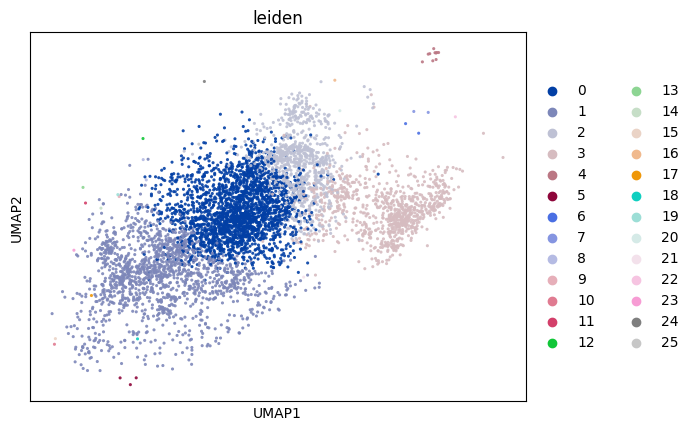

In [8]:
# Within CG258, lets look at the bacotypes by KL locus 
cg258_data = adata[adata.obs['Clonal group'] == 'CG258']
cg258_data.obs['K_locus'].value_counts()

# Within CG258, lets repeat leiden clustering and plot the UMAP annotated by KL locus 
sc.tl.leiden(cg258_data, resolution=0.25)
sc.pl.umap(cg258_data, color='leiden', size=20, alpha=0.9)

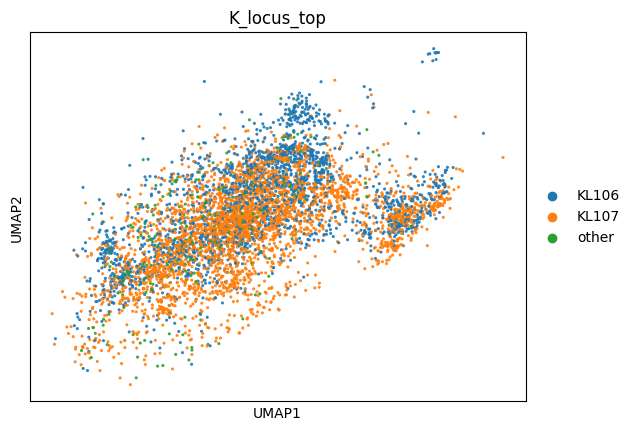

In [12]:
# Label KL106, KL107 and "other"
cg258_data.obs['K_locus'] = cg258_data.obs['K_locus'].astype(str)
cg258_data.obs['K_locus_top'] = cg258_data.obs['K_locus'].apply(lambda x: x if x in ['KL106', 'KL107'] else 'other')
cg258_data.obs['K_locus_top'] = cg258_data.obs['K_locus_top'].astype('category')

sc.pl.umap(cg258_data, color='K_locus_top', size=20, alpha=0.9)